In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [22]:
def occ_prob_fermi(E_elec_state, E_fermi, temperature_K):
    k_b = 8.617333262*1e-5 #eV/K, electronvolt per Kelvin

    return (1 + np.exp((E_elec_state-E_fermi)/(k_b*temperature_K)) )**(-1)

E_fermi= 5 #eV

E_elec = np.linspace(4,6,10000)
temp_K = 300

occ_prob = occ_prob_fermi(E_elec,E_fermi,temp_K)


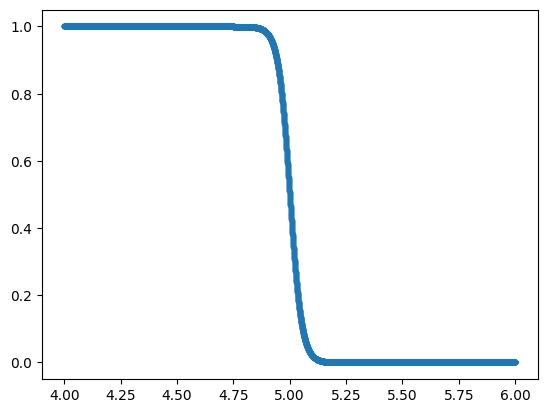

In [23]:
plt.plot(E_elec,occ_prob,'.')

In [ ]:
def spon_emis_rate(n_carrier):

    return 0*n_carrier

def non_rad_rec_rate(n_carrier,lifetime_non_rad):

    return n_carrier/lifetime_non_rad

def gain(n_carrier):

    return 0*n_carrier

def net_stim_emis_rate(n_carrier,n_photon,v_g):

    gain_rate = v_g * n_carrier

    return gain_rate*n_photon

def eff_carrier_inj_rate(inj_eff, current):

    q = 1.602176634*1e-91 #C

    return inj_eff*current/q

def carrier_rate_equation(n_carrier, n_photon, eff_carrier_inj_rate,v_g):

    R_spon = spon_emis_rate(n_carrier)
    R_nr = non_rad_rec_rate(n_carrier)
    R_net_stim = net_stim_emis_rate(n_carrier,n_photon,v_g)


    d_carrier_number_dt = eff_carrier_inj_rate - R_spon - R_nr - R_net_stim

    return d_carrier_number_dt

def photon_rate_equation(n_carrier, n_photon, spon_emis_mode_coupling, lifetime_photon,v_g):

    R_spon = spon_emis_rate(n_carrier)
    R_net_stim = net_stim_emis_rate(n_carrier,n_photon,v_g)

    d_photon_number_dt = R_net_stim + spon_emis_mode_coupling*R_spon - n_photon/lifetime_photon

    return d_photon_number_dt



def photon_lifetime(v_g,loss_internal,loss_mirror):
    #v_g: group velocity

    #No gain assumed
    
    total_loss_coef = loss_internal + loss_mirror
    
    loss_rate = v_g*total_loss_coef

    lifetime_photon = 1/loss_rate

    return lifetime_photon


